In [2]:
import MC_ln as mc
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
L = 256
T = [0.01, 0.15, 0.185, 0.22]
epsilon = 0.0
gamma = 1.0
A = 1.0
rho = 1.0
size = 0.1

for temp in T:
    path = f"Model/epsilon{epsilon}_gamma{gamma}/L{L}/T{temp:.3e}"
    mc.plot_results(path, L, temp, epsilon, rho, size)

path = f"Model/epsilon{epsilon}_gamma{gamma}/L{L}"
mc.plot_chi_vs_T(path, L)
mc.plot_eta_vs_T(path, L)

In [3]:
T = [0.05, 0.1, 0.15, 0.18, 0.2, 0.22, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
L = 128
epsilon = 0.0
gamma = 1.0
A = 1.0
rho = 1.0

for temp in T:
    path = f"Model/epsilon{epsilon}_gamma{gamma}/L{L}/T{temp:.3e}"
    mc.plot_results(path, L, temp, epsilon, rho, size=5)

path = f"Model/epsilon{epsilon}_gamma{gamma}/L{L}"
mc.plot_eta_vs_T(path, L)
path = f"Model/epsilon{epsilon}_gamma{gamma}"
mc.plot_chi_vs_L(path, T)
mc.plot_chi_vs_T_all_L(path)

base_path = Model/epsilon0.0_gamma1.0
n chi_files = 1


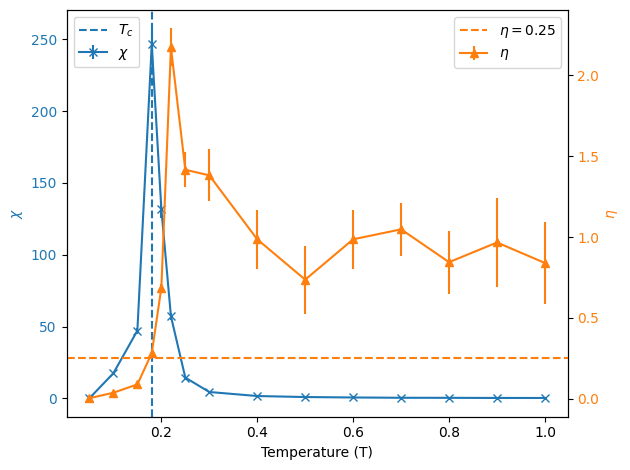

In [8]:
T = [0.05, 0.1, 0.15, 0.18, 0.2, 0.22, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
L = 128
epsilon = 0.0
gamma = 1.0
A = 1.0
rho = 1.0

chi = np.loadtxt(f"Model/epsilon{epsilon}_gamma{gamma}/L{L}/chi_L{L}.csv", delimiter=",", skiprows=1)
eta_xi = np.loadtxt(f"Model/epsilon{epsilon}_gamma{gamma}/L{L}/eta_xi_L{L}.csv", delimiter=",", skiprows=1)

T_chi = chi[:, 0]
chi_values = chi[:, 1]
chi_errors = chi[:, 2]

T_eta = eta_xi[:, 0]
eta_values = eta_xi[:, 1]
eta_errors = eta_xi[:, 2]

ax1 = plt.gca()
ax1.clear()

ax1.errorbar(T_chi, chi_values, yerr=chi_errors, fmt='-x', color='C0', label=r"$\chi$")
ax1.set_xlabel("Temperature (T)")
ax1.set_ylabel(r"$\chi$", color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.axvline(T_chi[np.argmax(chi_values)], color='C0', linestyle='--', label=r"$T_c$")

ax2 = ax1.twinx()
ax2.errorbar(T_eta, eta_values, yerr=eta_errors, fmt='-^', color='C1', label=r"$\eta$")
ax2.set_ylabel(r"$\eta$", color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax2.axhline(0.25, color='C1', linestyle='--', label=r"$\eta=0.25$")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"Model/epsilon{epsilon}_gamma{gamma}/L{L}/chi_eta_L{L}.pdf")